In [1]:
import math
import joblib
import keras

import numpy as np
import scipy as sp
import pandas as pd
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from keras import activations, layers, initializers
from keras.models import Model
from keras.optimizers.legacy import Adam

from src.inn_layers_v2 import IntAdd, IntDense, IntConv2D, IntDropout, IntFlatten, IntMultiply, IntSilu, IntGelu
from src.inn_layers_v2 import IntZeroPadding2D, IntBatchNormalization, IntRelu, IntTanh, IntMultiply_donet
from src.deeponet_wrapper import trainer

from matplotlib import pyplot as plt
import matplotlib.patches as patches
from src import inn_layers_v2 as innv2
from src import grid_augmentation as ga
from src import clust_augmentation as ca

import scienceplots
plt.style.use('science')

import warnings
warnings.filterwarnings("ignore")


In [2]:
params = {'xtick.labelsize':12,
          'ytick.labelsize':12,
          'axes.labelsize': 16,
          'axes.titlesize': 18}
plt.rcParams.update(params)

## Standard precise dataset

In [3]:
u_in = np.load("data/poisson1Dinput.npy")
g_out = np.load("data/poisson1Doutput.npy") * 20  # the output from u_in_lo is actually lower

y_space = np.linspace(0,1,u_in.shape[1])

## Ground truth interval data

In [4]:
u_in_lo = np.load("data/poisson1Dinput_low.npy")
u_in_hi = np.load("data/poisson1Dinput_high.npy")

g_out_lo = np.load("data/poisson1Doutput_high.npy") * 20  # the output from u_in_lo is actually lower
g_out_hi = np.load("data/poisson1Doutput_low.npy") * 20

In [5]:
u_int_0 = np.stack([u_in_lo, u_in_hi], axis=-1)
g_int_0 = np.stack([g_out_lo, g_out_hi], axis=-1)

### Train-Test split

In [6]:
n_total = u_in.shape[0] #2000
n_test = 1000  # thus, n_train = 1000
n_val = 100
rand = 42
idxs = np.arange(u_in_lo.shape[0])
idx_train, idx_test = train_test_split(idxs, test_size=n_test/n_total,
                                        random_state=rand)

In [7]:
u_int = np.expand_dims(u_int_0, axis=1)
g_int = np.expand_dims(g_int_0, axis=2)

In [8]:
## Pointwise data split
u_train, u_test = u_in[idx_train,...], u_in[idx_test,...]
g_train, g_test = g_out[idx_train,...], g_out[idx_test,...]

## Interval data split
u_int_train, u_int_test = u_int[idx_train,...], u_int[idx_test,...]
g_int_train, g_int_test = g_int[idx_train,...], g_int[idx_test,...]

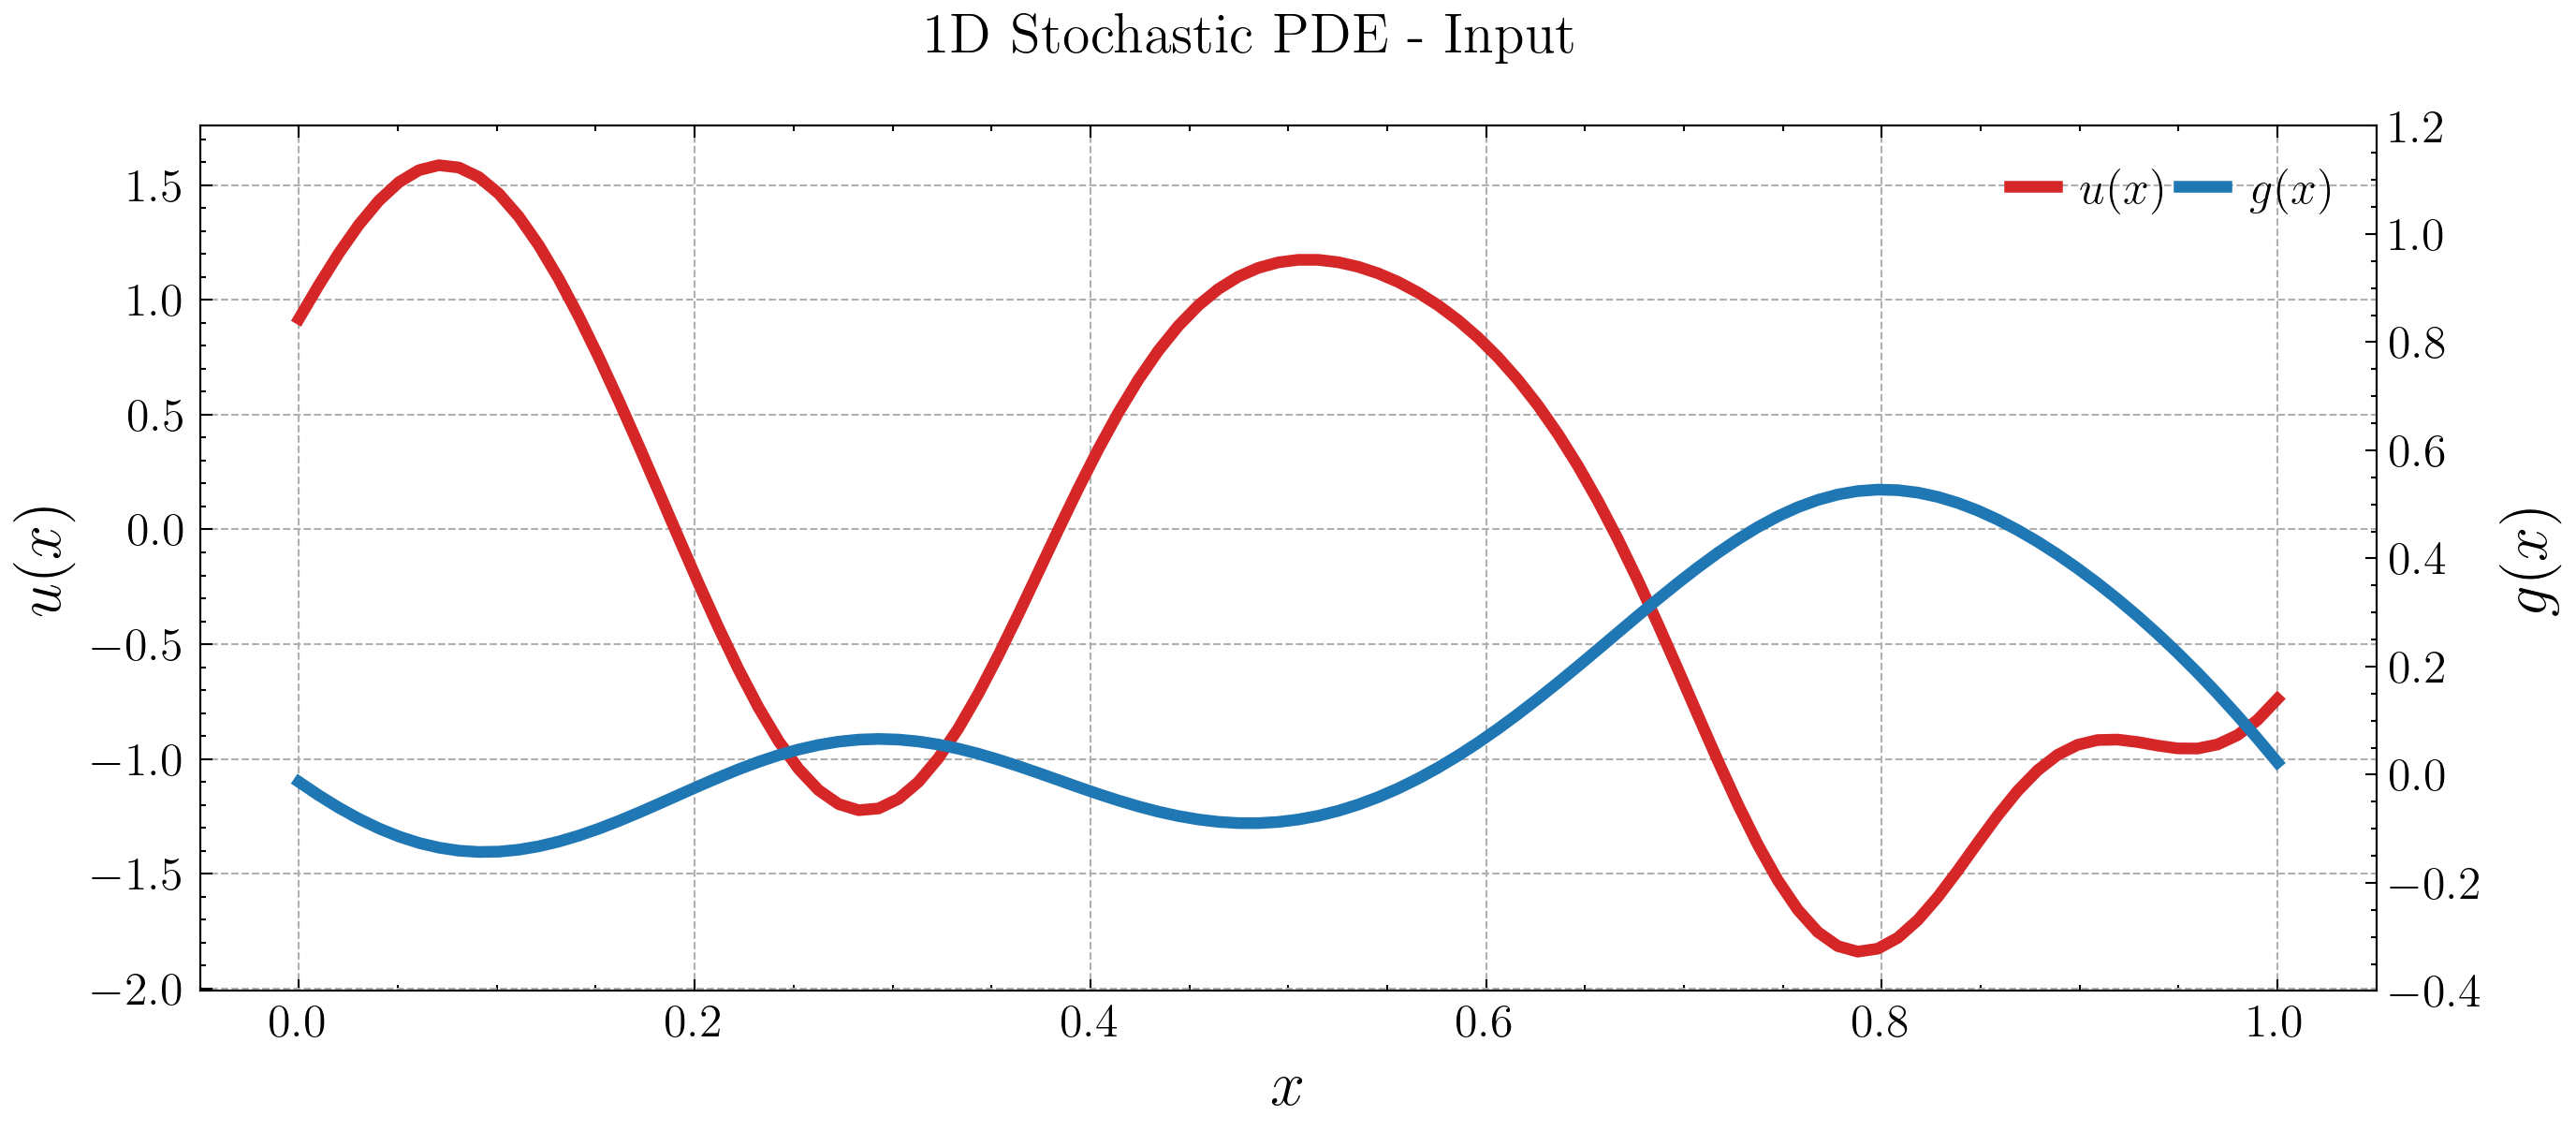

In [9]:
plt.rcParams['font.family'] = 'Times New Roman' 
plt.rcParams['font.size'] = 12
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

colormap = plt.cm.jet  
colors = [colormap(i) for i in np.linspace(0, 5, 20)]

fig2, ax1 = plt.subplots(figsize = (10, 4), dpi=300)
fig2.suptitle('1D Stochastic PDE - Input')

index = 0
i = 42
color = 'tab:red'
ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$u(x)$')
# ax1.plot(y_space, u_int_test[i,:,:,0].T, '--', color=color)
line1 = ax1.plot(y_space, u_test[i,:].T, '-', color=color, linewidth=3, label=r'$u(x)$')
# ax1.plot(y_space, u_int_test[i,:,:,1].T, '--', color=color)

ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel(r'$g(x)$')
# ax2.plot(y_space, g_int_test[i,:,:,0], '--', color=color)
line2 = ax2.plot(y_space, g_test[i,:].T, '-', color=color, linewidth=3, label=r'$g(x)$')
# ax2.plot(y_space, g_int_test[i,:,:,1], '--', color=color)
ax2.set_ylim(-0.4, 1.2)

# Combine legends from both axes
lines = [line1[0], line2[0]]
labels = [line.get_label() for line in lines]
plt.legend(lines, labels, loc='upper right', ncol=4, labelspacing=0.25, 
           columnspacing=0.25, handletextpad=0.5, handlelength=1)

ax1.grid(True, axis='both', linestyle='--', linewidth=0.5)
plt.margins(0)

plt.savefig("img/pointwise_1dPDE.pdf", dpi=300, format="pdf")
plt.show()

### Data Augmentation

In [10]:
# grid_res = [[a]*u_train.shape[1] for a in [15]]
# u_aug_train, g_aug_train = ga.construct_interval_grid(u_train, g_train, 
#                                                      grid_res=grid_res, n_shift=2, nmax_per_res=25)

In [11]:
u_aug_train_0, g_aug_train_0, u_clust, g_clust = ca.construct_interval(u_train, g_train, n_clusters=[5,10,20,50,75,100,150,200,300])

100%|██████████| 9/9 [00:08<00:00,  1.01it/s]


In [12]:
u_aug_train = np.expand_dims(u_aug_train_0, axis=1)
g_aug_train = np.expand_dims(g_aug_train_0, axis=2)

In [13]:
u_aug_train.shape, g_aug_train.shape

((814, 1, 100, 2), (814, 100, 1, 2))

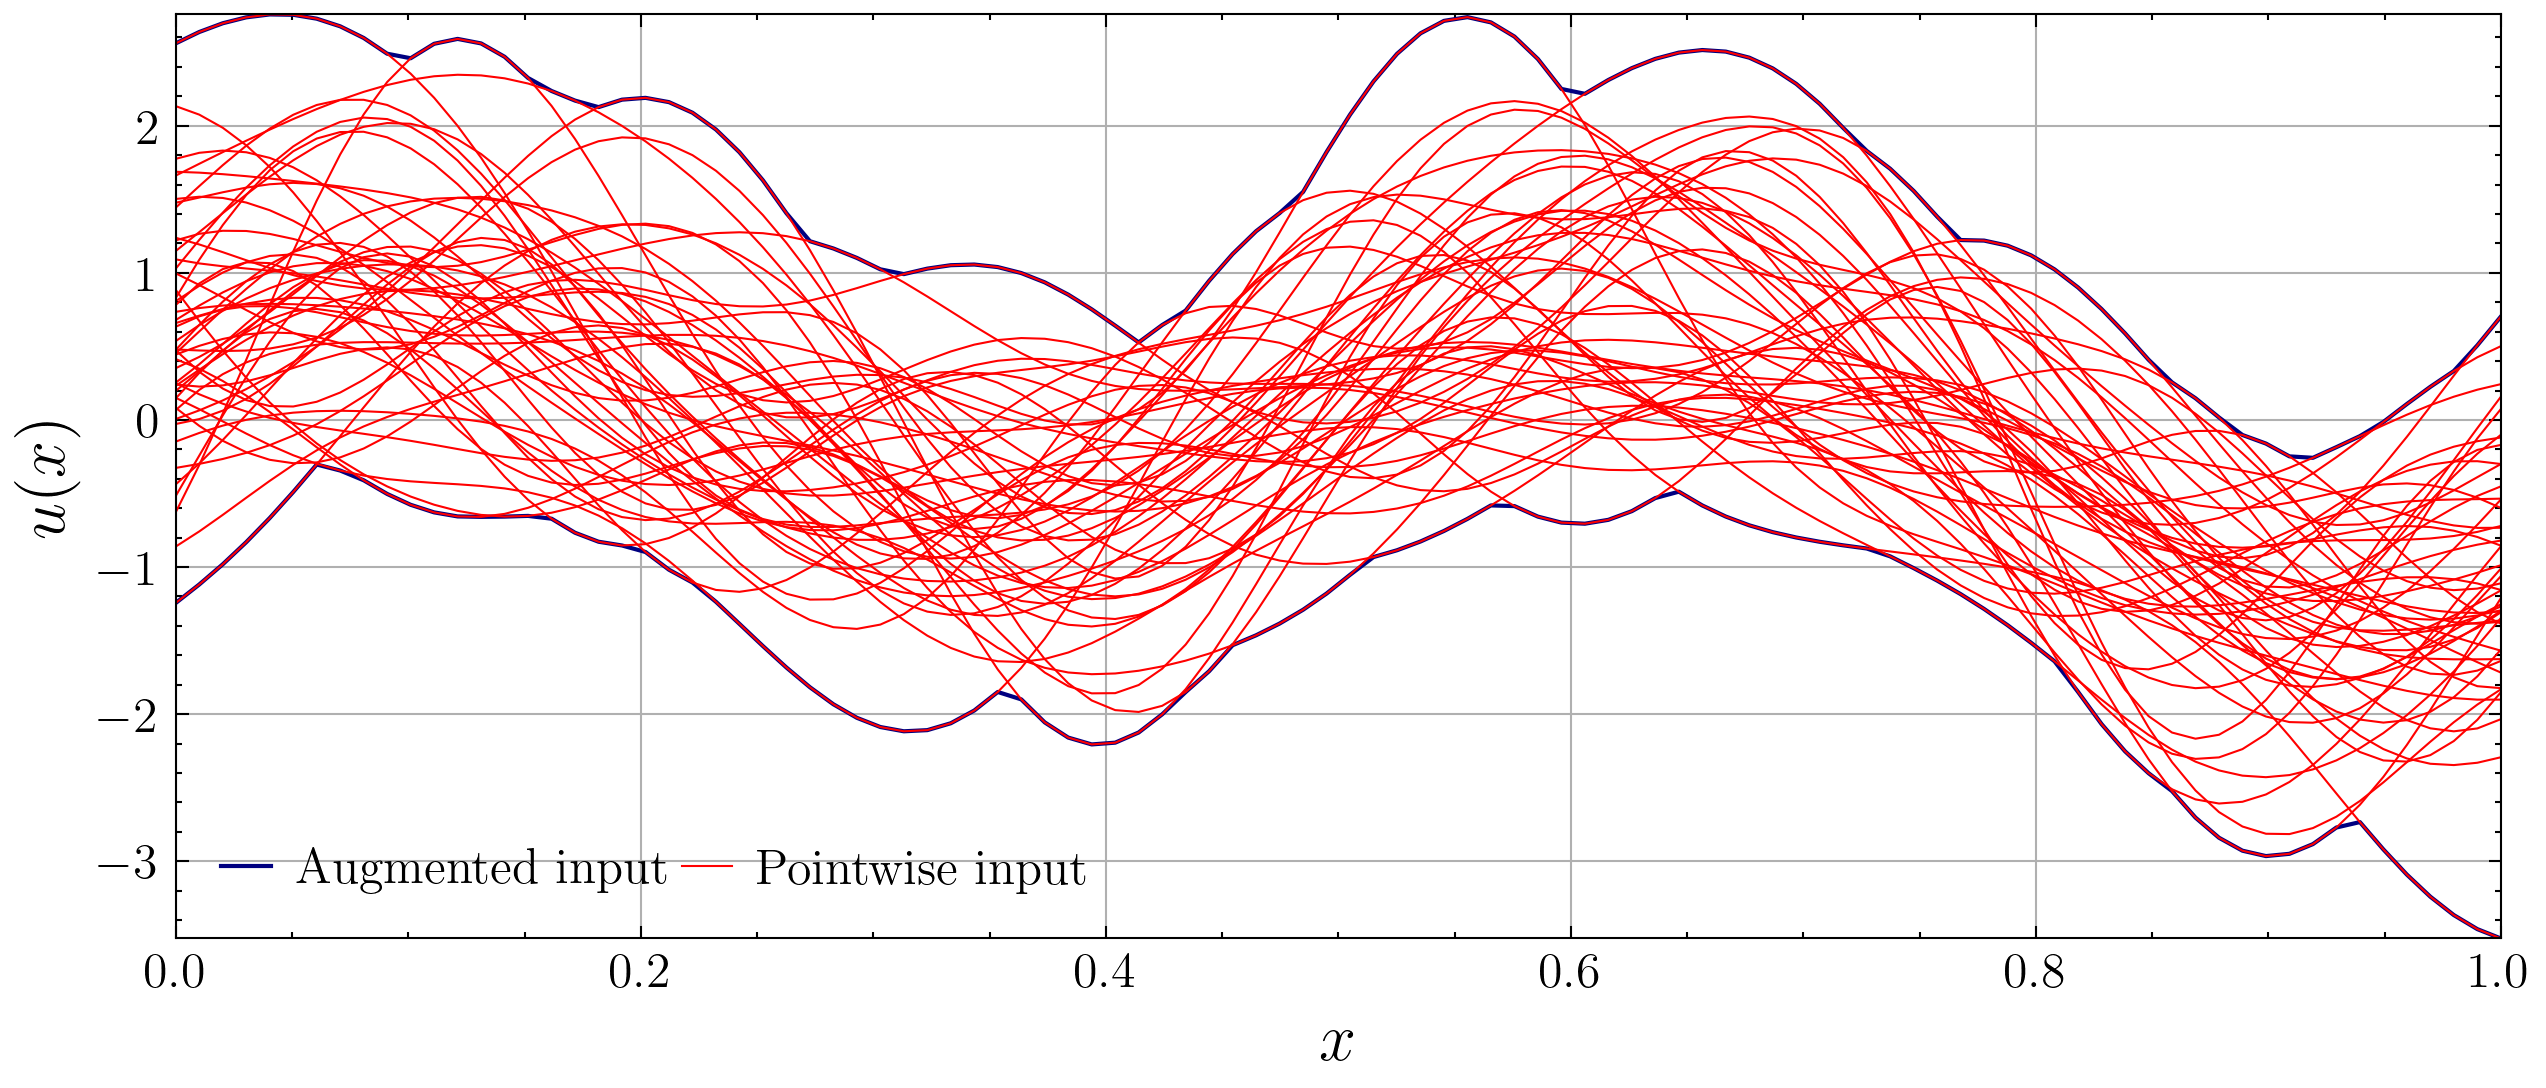

In [14]:
plt.rcParams['font.family'] = 'Times New Roman' 
plt.rcParams['font.size'] = 12
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

colormap = plt.cm.jet  
colors = [colormap(i) for i in np.linspace(0, 5, 20)]

fig2 = plt.figure(figsize = (10, 4), dpi=300)
# fig2.suptitle('1D Stochastic PDE - Augmented input')

index = 0
for i in [17]:
    plt.plot(y_space, u_aug_train[i,:,:,0].T, '-', color=colors[index], label='Augmented input')
    plt.plot(y_space, u_aug_train[i,:,:,1].T, '-', color=colors[index])
    for idxuc, uc in enumerate(u_clust[i]):
        if idxuc == 0:
            plt.plot(y_space, uc.T, '-', color="red", linewidth=0.5, label="Pointwise input")
        else:
            plt.plot(y_space, uc.T, '-', color="red", linewidth=0.5)
    index += 1
plt.legend(ncol=4, loc=3, labelspacing=0.25, columnspacing=0.25, handletextpad=0.5, handlelength=1)
plt.grid(True)
plt.margins(0)
plt.xlabel(r'$x$')
plt.ylabel(r'$u(x)$')

plt.savefig("img/augmented_input_1dpde.pdf", dpi=300, format="pdf")
plt.show()

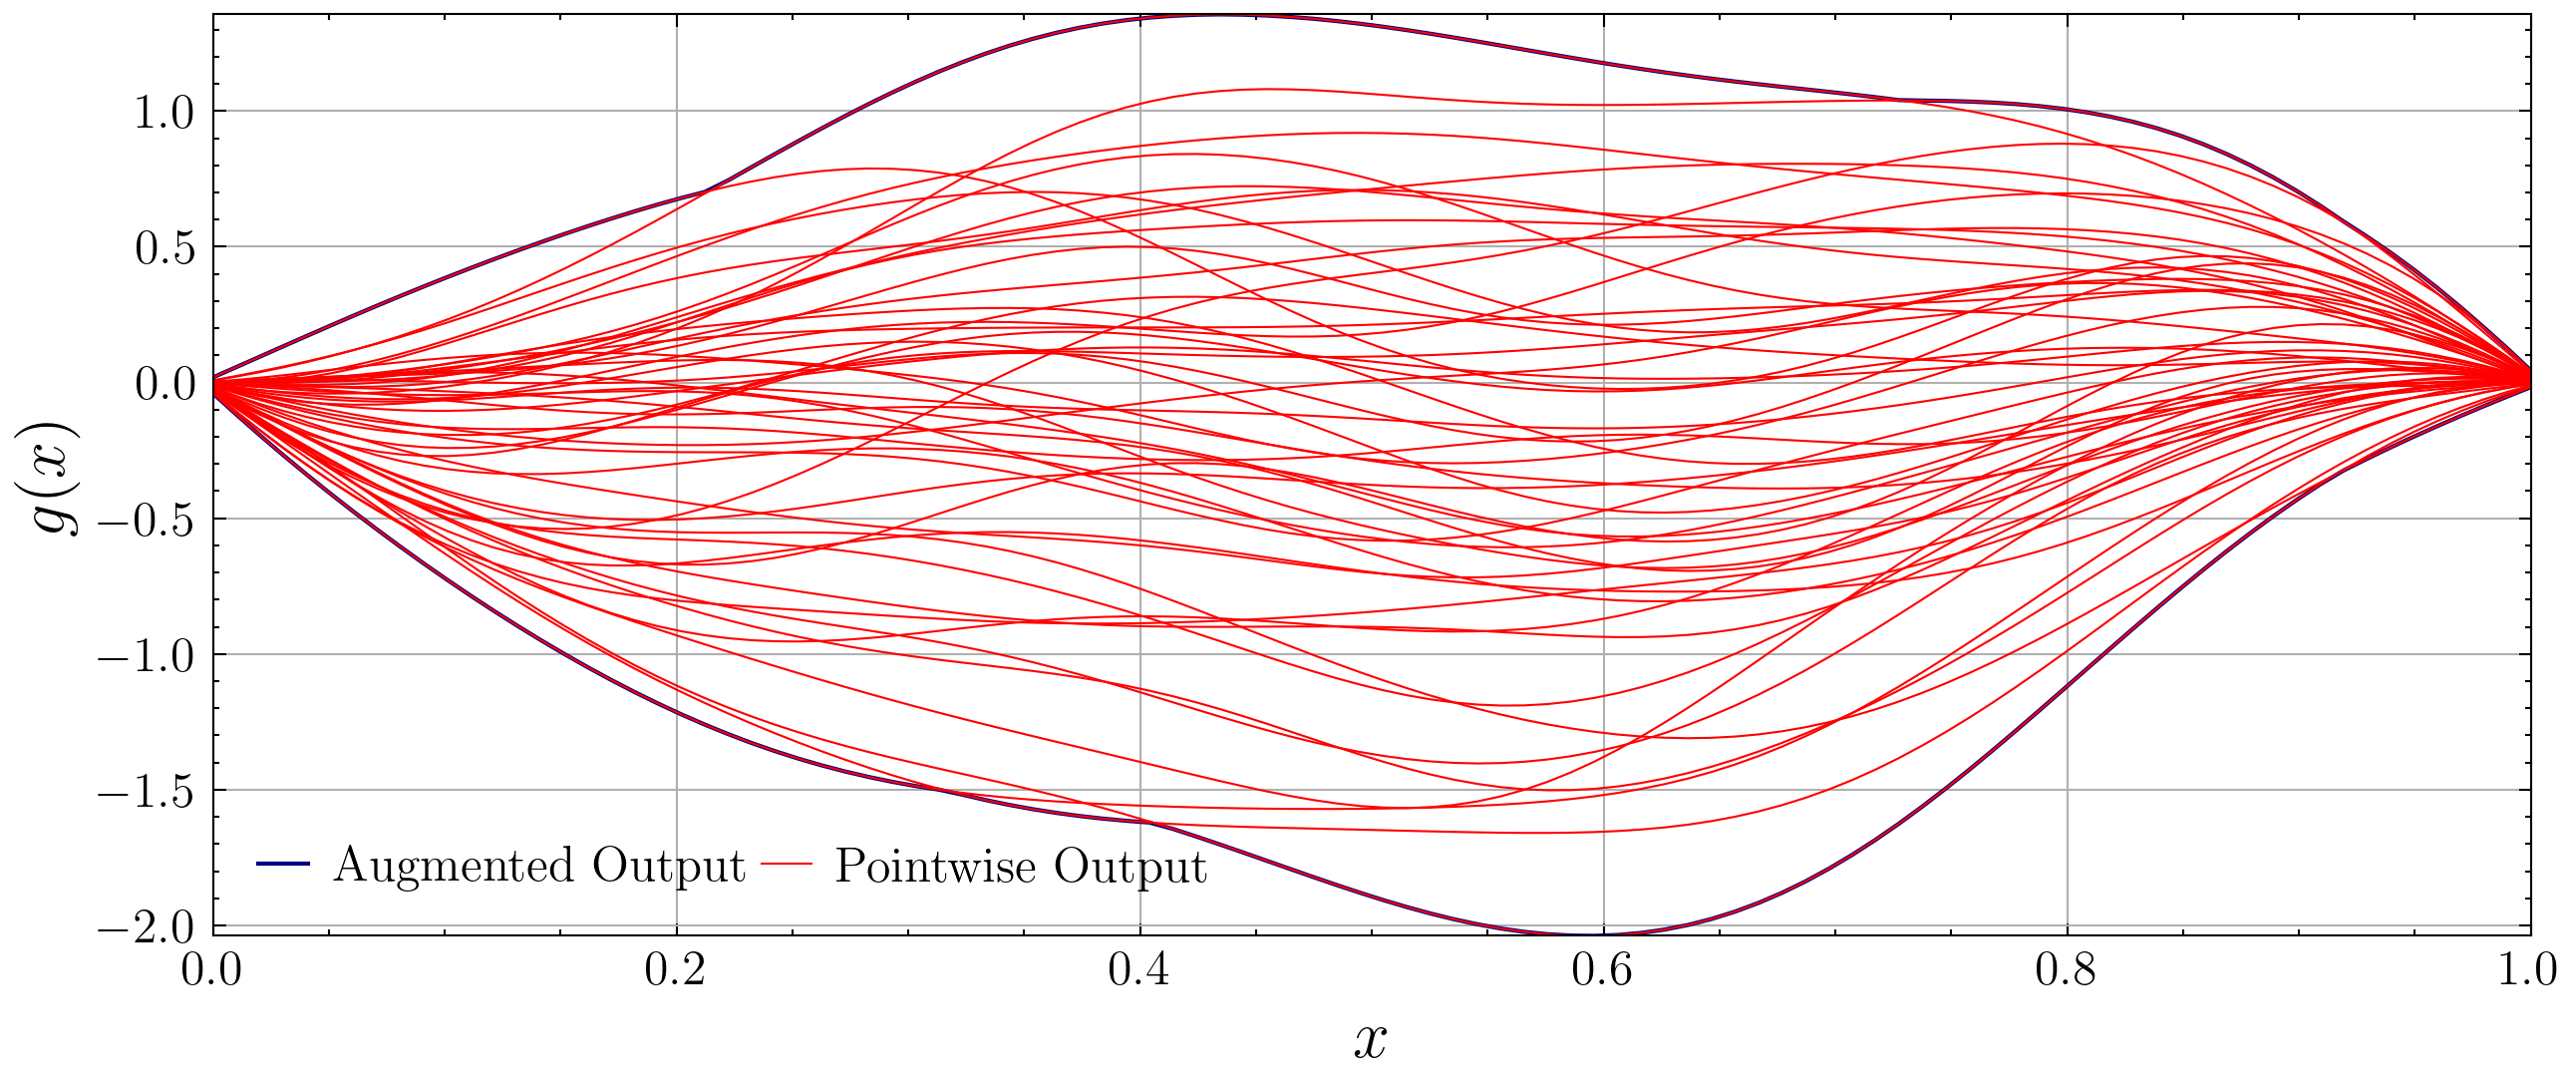

In [15]:
plt.rcParams['font.family'] = 'Times New Roman' 
plt.rcParams['font.size'] = 12
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

colormap = plt.cm.jet  
colors = [colormap(i) for i in np.linspace(0, 5, 20)]

fig2 = plt.figure(figsize = (10, 4), dpi=300)
# fig2.suptitle('1D Stochastic PDE - Augmented Output')

index = 0
for i in [17]:
    plt.plot(y_space, g_aug_train[i,:,:,0], '-', color=colors[index], label='Augmented Output')
    plt.plot(y_space, g_aug_train[i,:,:,1], '-', color=colors[index])
    for idxgc, gc in enumerate(g_clust[i]):
        if idxgc == 0:
            plt.plot(y_space, gc.T, '-', color="red", linewidth=0.5, label="Pointwise Output")
        else:
            plt.plot(y_space, gc.T, '-', color="red", linewidth=0.5)
    index += 1
plt.legend(ncol=4, loc=3, labelspacing=0.25, columnspacing=0.25, handletextpad=0.5, handlelength=1)
plt.grid(True)
plt.margins(0)
plt.xlabel(r'$x$')
plt.ylabel(r'$g(x)$')

plt.savefig("img/augmented_output_1dpde.pdf", dpi=300, format="pdf")
plt.show()

In [16]:
pde_dict = dict()
pde_dict['input_intv_low'] = u_aug_train[i,:,:,0]
pde_dict['input_intv_high'] = u_aug_train[i,:,:,1]
pde_dict['input_clust'] = u_clust[i]

pde_dict['output_intv_low'] = g_aug_train[i,:,:,0]
pde_dict['output_intv_high'] = g_aug_train[i,:,:,1]
pde_dict['output_clust'] = g_clust[i]

joblib.dump(pde_dict, "output/augmented_1dpde.pkl")

['output/augmented_1dpde.pkl']

## DeepONet

In [17]:
def build_mlp(inputs, output_features: int, 
              hidden_features: int, num_hidden_layers: int):
    """
    Builds an MLP regression model.
    
    Parameters:
        x: Input tensor.
        output_features (int): Number of output features.
        hidden_features (int): Number of units in each hidden layer.
        num_hidden_layers (int): Number of hidden layers.
    
    Returns:
        array: keras tensor.
    """
    x = inputs
    
    # Create hidden layers with tanh activation
    for i in range(num_hidden_layers):
        x = layers.Dense(hidden_features, activation='silu', name=f"trunk_{i}")(x)

    # Output layer with linear activation for regression
    outputs = layers.Dense(output_features, activation='linear', name="trunk_final")(x)
    
    return outputs

def build_nimlp(inputs, output_features: int, 
              hidden_features: int, num_hidden_layers: int):
    """
    Builds an Interval MLP regression model.
    
    Parameters:
        x: Input tensor.
        output_features (int): Number of output features.
        hidden_features (int): Number of units in each hidden layer.
        num_hidden_layers (int): Number of hidden layers.
    
    Returns:
        array: keras tensor.
    """
    x = inputs
    
    # Create hidden layers with tanh activation
    for i in range(num_hidden_layers):
        x = layers.Dense(hidden_features, activation="silu", name=f"branch_{i}")(x)

    # Output layer with linear activation for regression
    outputs = layers.Dense(output_features,  activation='linear', name="branch_final")(x)
    
    return outputs

In [18]:
def interval_deeponet(y_in_size, u_in_size, trunk_params, branch_params, out_feat=1):
    """_summary_

    Args:
        y_in_size (tuple): spatial input size
        u_in_size (tuple): function input size
        trunk_params (dict): trunk net parameters
        branch_params (dict): branch net parameters
        out_feat (int, optional): number of output feature. Defaults to 1.

    Returns:
        keras.Model: output model
    """
    y_input = layers.Input(y_in_size, name="y_input")
    u_input = layers.Input(u_in_size, name="u_input")

    # Trunk layer
    # y_in_lo = y_input[...,0]
    # y_in_hi = y_input[...,1]
    # y_in = [y_in_lo, y_in_hi]
    trunk_out = build_mlp(y_input, trunk_params["output_features"], 
                          trunk_params["hidden_features"], trunk_params["num_hidden_layers"])
    
    # Branch layer
    branch_out = build_nimlp(u_input, branch_params["output_features"], 
                                branch_params["hidden_features"], branch_params["num_hidden_layers"])

    # Multiply trunk and branch
    first_u = layers.Lambda(lambda t: t[..., 0:64])(branch_out)  # shape = (batch_size, 64)
    second_u = layers.Lambda(lambda t: t[..., 64:128])(branch_out) # shape = (batch_size, 64)
    mult1 = layers.Multiply()([trunk_out, first_u])
    mult2 = layers.Multiply()([trunk_out, second_u])
    merged = layers.Concatenate(axis=-1)([mult1, mult2])

    out = layers.Dense(out_feat, name="output_layer")(merged)

    model = Model(inputs=[y_input, u_input], outputs=out, name="DeepONet")

    return model

In [19]:
trunk_params=dict()
trunk_params["output_features"] = 64
trunk_params["hidden_features"] = 64
trunk_params["num_hidden_layers"] = 4

branch_params=dict()
branch_params["output_features"] = 128
branch_params["hidden_features"] = 64
branch_params["num_hidden_layers"] = 4

In [20]:
onet = interval_deeponet(y_in_size=(100,1), u_in_size=(1,200), trunk_params=trunk_params, 
                branch_params=branch_params, out_feat=2)

2026-02-23 11:40:49.423710: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-02-23 11:40:49.423736: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-23 11:40:49.423739: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-02-23 11:40:49.423921: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-23 11:40:49.423935: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [21]:
def linex(a):
    def linex_loss(target,y_pred):
        """Linear-exponential loss"""
        b = 2
        d1 = target[...,0,0] - y_pred[...,0]
        d2 = y_pred[...,1] - target[...,0,1]
        term1 = b*(tf.exp(-a*d1)+(a*d1)-1)
        term2 = b*(tf.exp(-a*d2)+(a*d2)-1)
        return tf.reduce_mean(term1 + term2)

    return linex_loss

def custom_loss(target, y_pred):
    term1 = tf.square((target[...,0,0] - y_pred[...,0]))
    term2 = tf.square((target[...,0,1] - y_pred[...,1]))
    mean_pred_width = tf.reduce_mean(y_pred[...,1] - y_pred[...,0])
    loss = tf.reduce_mean(term1+term2) + 7e-4 * mean_pred_width

    return loss

In [22]:
y_space_train = np.expand_dims(np.tile(y_space,(u_aug_train.shape[0],1)), axis=-1)
y_space_test = np.expand_dims(np.tile(y_space,(u_int_test.shape[0],1)), axis=-1)

In [23]:
y_space_train.shape, u_aug_train.shape, g_aug_train.shape

((814, 100, 1), (814, 1, 100, 2), (814, 100, 1, 2))

In [24]:
class DelayedBestWeights(tf.keras.callbacks.Callback):
    def __init__(self, monitor='loss', mode='min', start_epoch=100):
        super().__init__()
        self.monitor = monitor
        self.mode = mode
        self.start_epoch = start_epoch
        self.best_value = np.inf if mode == 'min' else -np.inf
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        current_value = logs.get(self.monitor)
        if epoch >= self.start_epoch:
            if (self.mode == 'min' and current_value < self.best_value) or \
               (self.mode == 'max' and current_value > self.best_value):
                self.best_value = current_value
                self.best_weights = self.model.get_weights()
                print(f" Best weights updated at epoch {epoch+1} with {self.monitor}={current_value:.4f}")

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)
            print(f"Restored best model from epoch after {self.start_epoch} "
                  f"with {self.monitor}={self.best_value:.4f}")
        else:
            print(f"No improvement found after epoch {self.start_epoch}")

In [25]:
class ConformalCalib():
    def __init__(self, y_l_calib, y_u_calib, alpha=0.1, method="interval"):
        assert method in ["interval","local","spatial"]
        self.y_l_calib = y_l_calib
        self.y_u_calib = y_u_calib
        self.alpha = alpha
        self.method = method
        self.q_conformal = 0
        self.residuals = None

    def calibrate(self, pred_l, pred_u):
        assert np.ndim(pred_l) == np.ndim(self.y_l_calib)
        if self.method == "interval":
            residuals = np.maximum(pred_l - self.y_l_calib, self.y_u_calib - pred_u)
        elif self.method == "local":
            interval_length = pred_u - pred_l
            residuals = np.maximum(pred_l - self.y_l_calib, self.y_u_calib - pred_u)/interval_length
        else:
            raise ValueError("Method haven't been implemented")

        n_cal = len(residuals)
        if self.alpha <= 1 and self.alpha > 0:
            quantile_level = np.ceil((n_cal + 1) * (1 - self.alpha)) / n_cal
            if quantile_level > 1:
                print(f"Warning: Quantile level = {quantile_level} calculated. Check alpha and n_cal. Setting quantile level to 1.")
                quantile_level = 1
            elif  quantile_level <= 0:
                print(f"Warning: Quantile level = {quantile_level} calculated. Check alpha and n_cal. Setting quantile level to 0.")
                quantile_level = 0
            else:
                pass

        elif self.alpha > 1:
            raise ValueError("alpha greater than 1")
        else:
            quantile_level = 1

        self.q_conformal = np.quantile(
                            residuals,
                            quantile_level
                        )
        self.residuals = residuals

    def conformalize(self, pred_l, pred_u):
        if self.method == "interval":
            lb_conf = pred_l - self.q_conformal
            ub_conf = pred_u + self.q_conformal
        elif self.method == "local":
            pred_length = pred_u - pred_l
            pred_mid = (pred_l + pred_u)/2
            lb_conf = pred_mid - (self.q_conformal * pred_length)
            ub_conf = pred_mid + (self.q_conformal * pred_length)
        else:
            raise ValueError("Method haven't been implemented")

        return lb_conf, ub_conf


In [26]:
def run_experiment(trunk_params, branch_params, u_int_train, y_int_train, g_int_train,
                   u_test_int, y_test_int, g_test_int, cal_source="augmented", conformal_fun="interval",
                   alpha=0.1, repetitions=10, n_train = 500, epochs=500, n_cal=50, verbose=False):
    """Run the experiment with the given model and data."""

    results = []

    # Choose n_train random as training data
    for seed in tqdm(range(repetitions)):
        # Compile model
        model = interval_deeponet(y_in_size=(100,1), u_in_size=(1,200), trunk_params=trunk_params, 
                branch_params=branch_params, out_feat=2)
        model.compile(
            optimizer=keras.optimizers.legacy.Adam(learning_rate=1e-3),
            loss=custom_loss
        )

        data = dict()
        np.random.seed(seed)
        training_indices = np.arange(u_int_train.shape[0])
        idx_train = np.random.choice(training_indices, size=n_train, replace=False)
        u_train_int = u_int_train[idx_train,...]
        y_train_int = y_int_train[idx_train,...]
        g_train_int = g_int_train[idx_train,...]

        u_int_test = u_test_int.copy()
        y_int_test = y_test_int.copy()
        g_int_test = g_test_int.copy()
        if cal_source == "augmented":
            assert n_cal + n_train <= u_int_train.shape[0], "Not enough data for training and calibration"
            calibration_indices = np.setdiff1d(training_indices, idx_train)
            idx_cal = np.random.choice(calibration_indices, size=n_cal, replace=False)
            u_cal_int = u_int_train[idx_cal]
            y_cal_int = y_int_train[idx_cal]
            g_cal_int = g_int_train[idx_cal]
        else:
            test_indices = np.arange(u_int_test.shape[0])
            idx_cal = np.random.choice(test_indices, size=n_cal, replace=False)
            u_cal_int = u_int_test[idx_cal]
            y_cal_int = y_int_test[idx_cal]
            g_cal_int = g_int_test[idx_cal]
            u_int_test = np.delete(u_int_test, idx_cal, axis=0)
            y_int_test = np.delete(y_int_test, idx_cal, axis=0)
            g_int_test = np.delete(g_int_test, idx_cal, axis=0)

        u_int_train_in = np.concatenate([u_train_int[...,0], u_train_int[...,1]], axis=-1)
        u_int_cal_in = np.concatenate([u_cal_int[...,0], u_cal_int[...,1]], axis=-1)

        best_weights_cb = DelayedBestWeights(monitor='val_loss', mode='min', start_epoch=100)

        # Train model
        hist = model.fit(x=[y_train_int, u_int_train_in], y=g_train_int, 
                   validation_data=([y_cal_int, u_int_cal_in], g_cal_int), 
                   epochs=epochs, callbacks=[best_weights_cb], verbose=verbose, batch_size=128)
        # Conformal calibration
        if n_cal > 0:
            pred_cal = model.predict([y_cal_int, u_int_cal_in])
            conformal_calib = ConformalCalib(g_cal_int[...,0], g_cal_int[...,1], alpha=alpha, method=conformal_fun)
            conformal_calib.calibrate(pred_cal[...,0][...,None], pred_cal[...,1][...,None])

        # Evaluate model
        u_int_test_in = np.concatenate([u_int_test[...,0], u_int_test[...,1]], axis=-1)
        pred = model.predict([y_int_test, u_int_test_in])
        pred_conf = np.zeros_like(pred)
        if n_cal > 0:
            pred_conf[...,0], pred_conf[...,1] = conformal_calib.conformalize(pred[...,0], pred[...,1])
        data["u_train"] = u_train_int
        data["y_train"] = y_train_int
        data["g_train"] = g_train_int
        data["u_test"] = u_int_test
        data["y_test"] = y_int_test
        data["g_test"] = g_int_test
        data["pred"] = pred
        data["pred_conf"] = pred_conf
        data["history"] = hist.history

        results.append(data)
        
    return results

In [27]:
for ncal in [10, 25]:
    print(f"##### Running experiment with n_cal={ncal} #####")
    results = run_experiment(trunk_params, branch_params, u_aug_train, y_space_train, g_aug_train,
                       u_int_test, y_space_test, g_int_test, cal_source="interval", alpha=0.05,
                       conformal_fun="interval", n_cal=ncal, repetitions=10, n_train=500, epochs=1000, verbose=False)
    joblib.dump(results, f"output/deeponet1d_conf/deeponet1d_aug_naive_ntrain500_calibint_conf{ncal}_a050.pkl")

##### Running experiment with n_cal=10 #####


  0%|          | 0/10 [00:00<?, ?it/s]2026-02-23 11:40:50.399157: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


 Best weights updated at epoch 101 with val_loss=0.1273
 Best weights updated at epoch 103 with val_loss=0.1256
 Best weights updated at epoch 105 with val_loss=0.1203
Restored best model from epoch after 100 with val_loss=0.1203
31/31 [==============================] - 1s 15ms/step


 10%|█         | 1/10 [02:16<20:29, 136.66s/it]

 Best weights updated at epoch 101 with val_loss=0.1036
 Best weights updated at epoch 102 with val_loss=0.0926
 Best weights updated at epoch 107 with val_loss=0.0895
 Best weights updated at epoch 119 with val_loss=0.0867
 Best weights updated at epoch 126 with val_loss=0.0829
 Best weights updated at epoch 145 with val_loss=0.0822
 Best weights updated at epoch 186 with val_loss=0.0820
 Best weights updated at epoch 192 with val_loss=0.0815
 Best weights updated at epoch 200 with val_loss=0.0805
 Best weights updated at epoch 232 with val_loss=0.0802
 Best weights updated at epoch 320 with val_loss=0.0773
Restored best model from epoch after 100 with val_loss=0.0773
31/31 [==============================] - 1s 15ms/step


...

 80%|████████  | 8/10 [18:56<04:47, 143.82s/it]

 Best weights updated at epoch 101 with val_loss=0.1465
 Best weights updated at epoch 103 with val_loss=0.1419
 Best weights updated at epoch 122 with val_loss=0.1417
 Best weights updated at epoch 222 with val_loss=0.1405
 Best weights updated at epoch 232 with val_loss=0.1397
 Best weights updated at epoch 281 with val_loss=0.1390
 Best weights updated at epoch 285 with val_loss=0.1351
 Best weights updated at epoch 286 with val_loss=0.1294
 Best weights updated at epoch 289 with val_loss=0.1268
 Best weights updated at epoch 291 with val_loss=0.1255
 Best weights updated at epoch 292 with val_loss=0.1210
 Best weights updated at epoch 298 with val_loss=0.1200
 Best weights updated at epoch 303 with val_loss=0.1073
 Best weights updated at epoch 305 with val_loss=0.1059
 Best weights updated at epoch 312 with val_loss=0.1040
 Best weights updated at epoch 397 with val_loss=0.1021
 Best weights updated at epoch 424 with val_loss=0.0994
 Best weights updated at epoch 489 with val_loss

 90%|█████████ | 9/10 [21:23<02:24, 144.71s/it]

 Best weights updated at epoch 101 with val_loss=0.1569
 Best weights updated at epoch 102 with val_loss=0.1560
 Best weights updated at epoch 103 with val_loss=0.1471
 Best weights updated at epoch 105 with val_loss=0.1420
 Best weights updated at epoch 374 with val_loss=0.1364
 Best weights updated at epoch 623 with val_loss=0.1319
 Best weights updated at epoch 653 with val_loss=0.1253
 Best weights updated at epoch 790 with val_loss=0.1246
 Best weights updated at epoch 826 with val_loss=0.1203
 Best weights updated at epoch 973 with val_loss=0.1181
 Best weights updated at epoch 974 with val_loss=0.1147
Restored best model from epoch after 100 with val_loss=0.1147
31/31 [==============================] - 2s 45ms/step


100%|██████████| 10/10 [23:44<00:00, 142.48s/it]


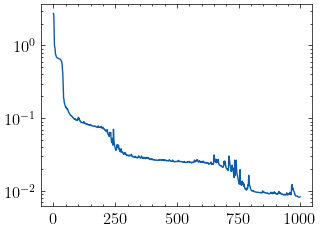

In [28]:
plt.semilogy(results[0]['history']['loss'])

## Predict

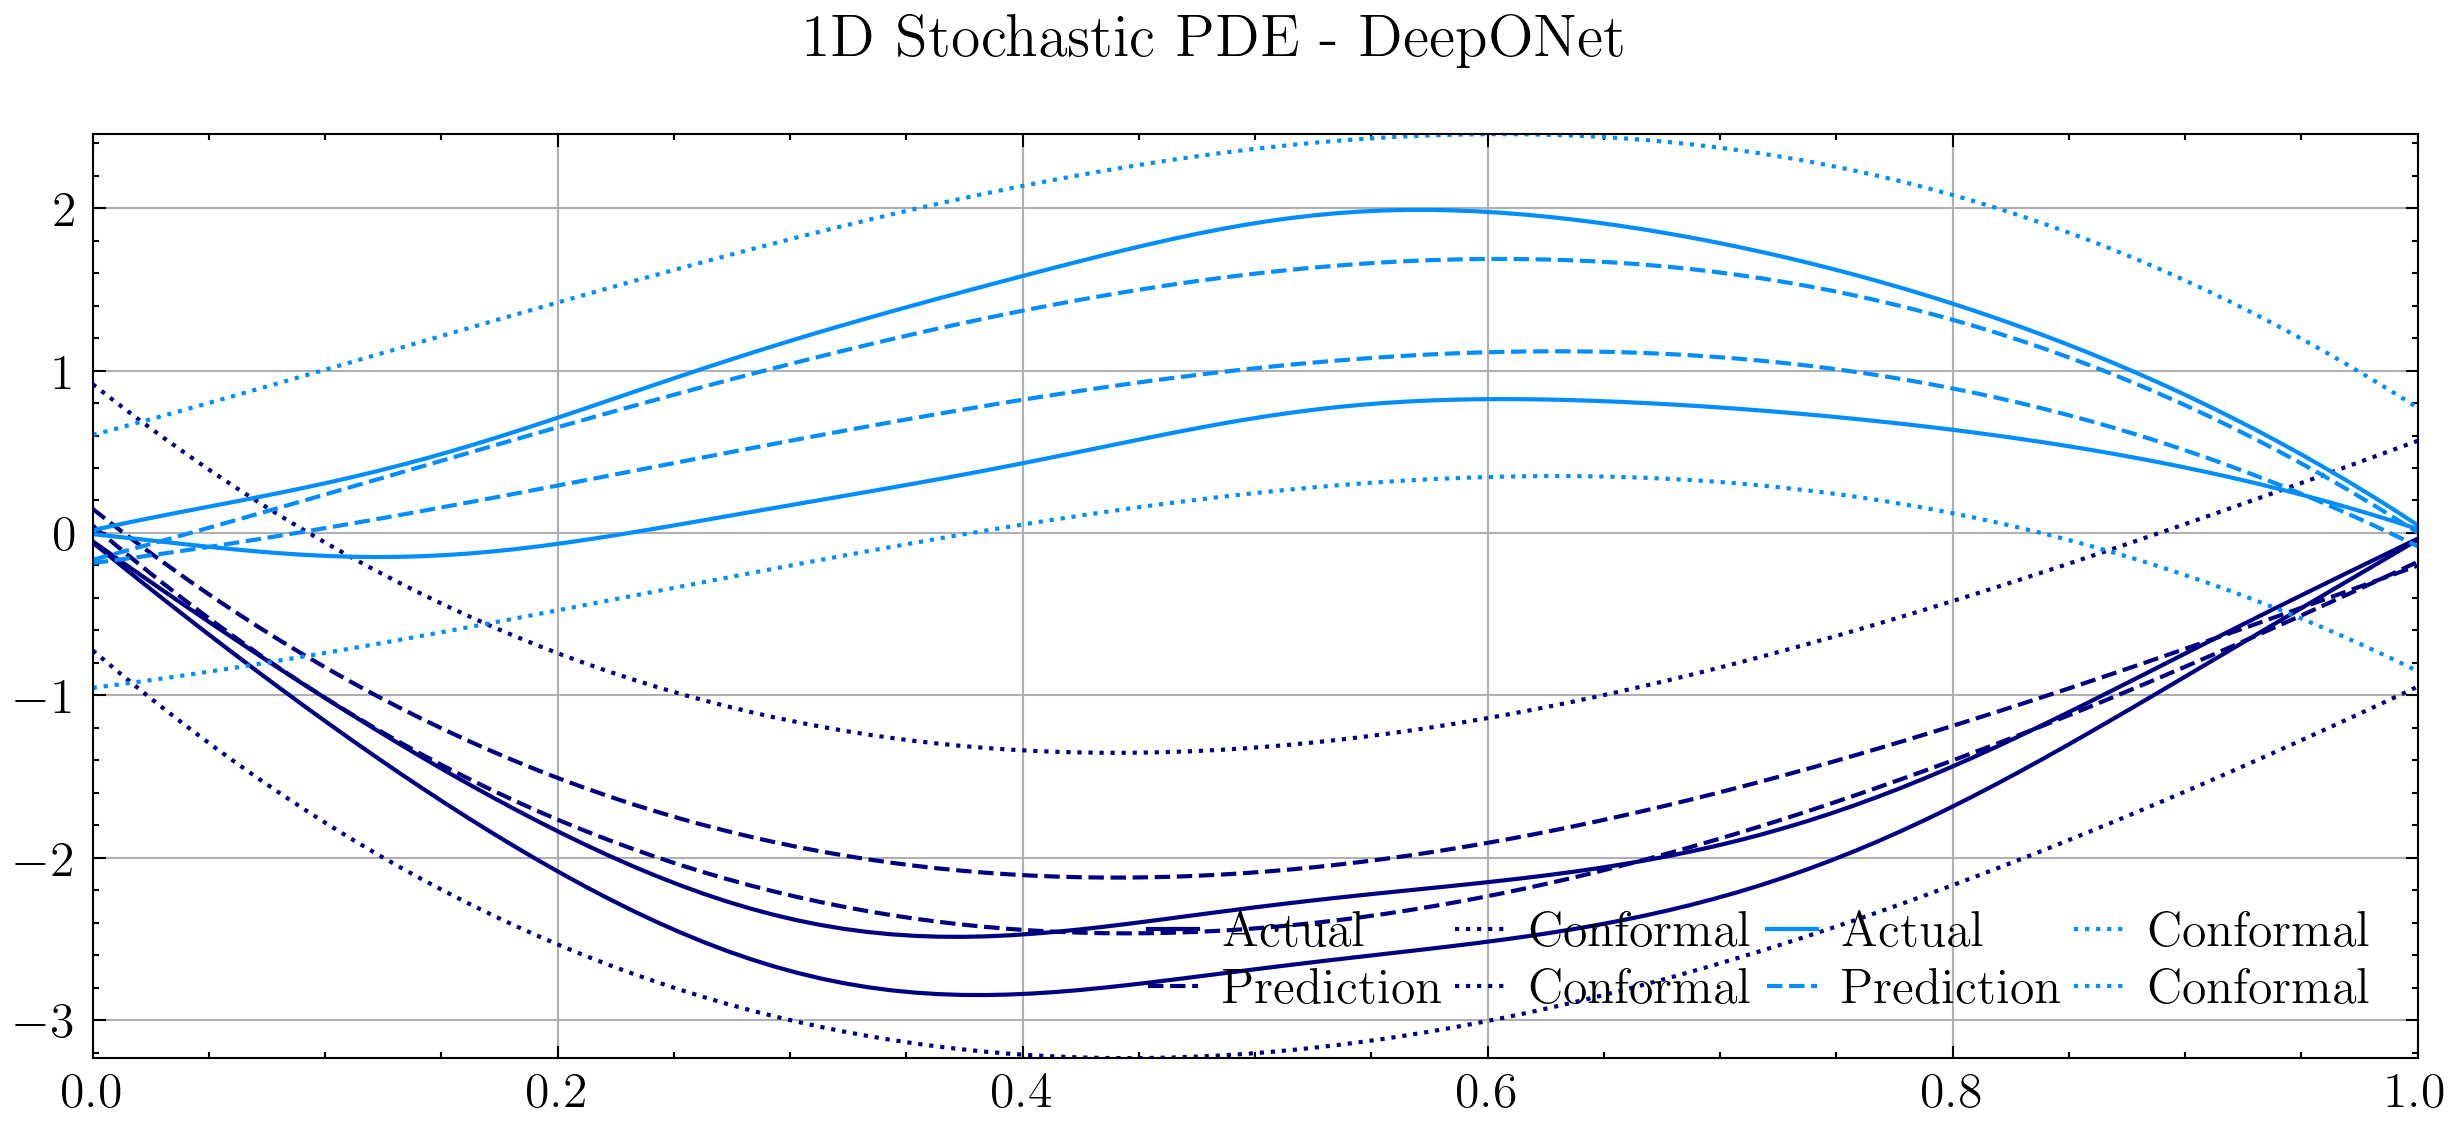

In [29]:
idx=0
preds = results[idx]["pred"]
preds_conf = results[idx]["pred_conf"]
g_int_test = results[idx]["g_test"]

plt.rcParams['font.family'] = 'Times New Roman' 
plt.rcParams['font.size'] = 12
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

colormap = plt.cm.jet  
colors = [colormap(i) for i in np.linspace(0, 5, 20)]

fig2 = plt.figure(figsize = (10, 4), dpi=300)
fig2.suptitle('1D Stochastic PDE - DeepONet')

index = 0
for i in [39,66]:
    plt.plot(y_space, g_int_test[i,:,:,0], color=colors[index], label='Actual')
    plt.plot(y_space, g_int_test[i,:,:,1], color=colors[index])
    plt.plot(y_space, preds[i,:,0].T, '--', color=colors[index], label='Prediction')
    plt.plot(y_space, preds[i,:,1].T, '--', color=colors[index])
    plt.plot(y_space, preds_conf[i,:,0].T, ':', color=colors[index], label='Conformal')
    plt.plot(y_space, preds_conf[i,:,1].T, ':', color=colors[index], label='Conformal')
    index += 1
plt.legend(ncol=4, loc=4, labelspacing=0.25, columnspacing=0.25, handletextpad=0.5, handlelength=1)
plt.grid(True)
plt.margins(0)